In [15]:
import torch
from torch.utils.data import DataLoader, Dataset

from PIL import Image
import numpy as np
from clothing_segmentation import HumanParser
import pandas as pd
from pathlib import Path

from torchvision import transforms as T



class SyntheticTryonDatasetFromDisk(Dataset):
    def __init__(self, path='/mnt/datadrive/asos_dataset/prepared_256/tensors/'):
        self.path = Path(path)
        self.glob=sorted(self.path.rglob('*.pt'), key=lambda x: int(x.stem))
        print(self.glob[0])

    def __len__(self):
        return len(self.glob)
    
    def __getitem__(self, idx):
        tensor_path = self.glob[idx]
        record = torch.load(tensor_path)
        return record


import pickle
from matplotlib import pyplot as plt
xxxx = SyntheticTryonDatasetFromDisk()
bad_list=[]
from tqdm import tqdm
for idx, i in enumerate(tqdm(xxxx, total=len(xxxx))):
    # print(i)
    print(i['person_poses'].shape)
    
    
    # print(i['garment_poses'])
    break


/mnt/datadrive/asos_dataset/prepared_64/tensors/0.pt


  0%|          | 0/604 [00:00<?, ?it/s]

(18, 2)


In [34]:
# def __call__(self, input_image, detect_resolution=512, include_hand=False, include_face=False):
    
#     if not isinstance(input_image, np.ndarray):
#         input_image = np.array(input_image, dtype=np.uint8)

#     input_image = HWC3(input_image)
#     input_image = resize_image(input_image, detect_resolution)

#     poses = self.detect_poses(input_image, include_hand, include_face)
    
#     xy=[]
#     if len(poses)>0:
#         for point in poses[0].body.keypoints:
#             if point is not None:
#                 xy.append([point.x, point.y])
#             else:
#                 xy.append([0, 0])
#         return np.array(xy)
#     else:
#         return None

from controlnet_aux import OpenposeDetector
from controlnet_aux.open_pose import HWC3, resize_image
from diffusers.utils import load_image
input_image = target_img
if not isinstance(input_image, np.ndarray):
    input_image = np.array(input_image, dtype=np.uint8)
input_image = input_image.astype(np.uint8)

input_image = HWC3(input_image)
input_image = resize_image(input_image, 512)

poses = dataset.openpose.detect_poses(input_image, include_hand=False, include_face=False)

# xy=[]
# if len(poses)>0:
#     for point in poses[0].body.keypoints:
#         if point is not None:
#             xy.append([point.x, point.y])
#         else:
#             xy.append([0, 0])
#     return np.array(xy)
# else:
#     return None
poses

[]

In [31]:


target_img

array([[[0.9882353 , 0.9882353 , 0.9882353 ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        ...,
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ]],

       [[1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        ...,
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ]],

       [[1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        ...,
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ]],

       ...,

       [[1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1

In [19]:
dataset.items_reverse_index[65]

array(['/mnt/datadrive/asos_dataset/tshirts_orig_bigest/65/2288.png',
       '/mnt/datadrive/asos_dataset/tshirts_orig_bigest/65/2289.png',
       '/mnt/datadrive/asos_dataset/tshirts_orig_bigest/65/2290.png'],
      dtype=object)

In [15]:
bad_list

[65,
 109,
 128,
 135,
 136,
 179,
 212,
 227,
 232,
 250,
 269,
 318,
 361,
 440,
 455,
 465,
 466,
 495,
 531,
 534,
 535,
 545,
 568]

In [1]:
# import pickle 

# import torch
# from torch.utils.data import DataLoader, Dataset

# from pathlib import Path
# from PIL import Image
# import numpy as np
# from clothing_segmentation import HumanParser
# import pandas as pd

# from torchvision import transforms as T


# from controlnet_aux import OpenposeDetector
# from controlnet_aux.open_pose import HWC3, resize_image
# from diffusers.utils import load_image



# class MyOpenPoseDetector(OpenposeDetector):
    
#     def __call__(self, input_image, detect_resolution=512, include_hand=False, include_face=False):
       
#         if not isinstance(input_image, np.ndarray):
#             input_image = np.array(input_image, dtype=np.uint8)

#         input_image = HWC3(input_image)
#         input_image = resize_image(input_image, detect_resolution)

#         poses = self.detect_poses(input_image, include_hand, include_face)
#         xy=[]
#         if len(poses)>0:
#             for point in poses[0].body.keypoints:
#                 if point is not None:
#                     xy.append([point.x, point.y])
#                 else:
#                     xy.append([0, 0])
#             return np.array(xy)
#         else:
#             return None
        

# import itertools
# class SyntheticTryonDataset(Dataset):
#     def __init__(self, image_size=(64,64), pose_size=(18, 2), apply_transform=True):
#         self.cache = {}
#         self.human_parser = HumanParser()
#         self.transform = T.Compose([
#             # T.Resize(image_size),
#             # T.CenterCrop(image_size),
#             T.ToTensor(),
#         ])
#         self.apply_transform = apply_transform
#         # self.df = pd.read_csv('/home/roman/tryondiffusion_implementation/tryondiffusion_danny/all_imgs.csv')
#         self.df = pd.read_csv('/home/roman/tryondiffusion_implementation/tryondiffusion_danny/all_imgs_clean_80756_total.csv')
#         print(len(self.df))
#         self.df = self.df[~self.df['pose_is_none']]
#         print(len(self.df))
#         self.items_reverse_index = {}
#         self.items_reverse_index_poses = {}
#         for group_idx, group in self.df.groupby(by='item_idx'):
#             self.items_reverse_index[group_idx] = [{"fullpath":fp, "pose_512":pose} for fp, pose in zip(group['fullpath'].values, group['pose_512'].values)]        

#         self.items_reverse_index3 = {}
#         key_idx=0
#         for k,v in self.items_reverse_index.items():
#             permutations = list(itertools.permutations(v, 2))
#             for i in permutations:
#                 self.items_reverse_index3[key_idx] = i
#                 key_idx+=1

#         print(len(self.items_reverse_index3))
#         self.image_size = image_size
#         # self.pose_size = pose_size
#         self.openpose = MyOpenPoseDetector.from_pretrained("lllyasviel/ControlNet")

        
#     def __len__(self):
#         return len(self.items_reverse_index3)
    
#     def prepare_clothing_agnostic(self, img, hp_mask)-> np.array: 
#         # classes_to_rm=[4,6] 
#         classes_to_rm=[4]      
#         # def get_clothing_agnostic(image, hp_mask, classes_to_rm=[4,6]):
#         bg_color = (255,255,255)
#         assert img.shape[:-1] == hp_mask.shape
#         # cloths_to_rm_mask = np.zeros(hp_mask.shape)
#         # for i in np.unique(res):
#         #     if i in classes_to_rm:
#         #         cloths_to_rm_mask[res==i] = 255
#         cloths_to_rm_mask = np.isin(hp_mask, classes_to_rm)
#         img[cloths_to_rm_mask!=0] = bg_color
#         return img
        
#     def prepare_segmented_garment(self, img, hp_mask)-> np.array:
#         # classes_to_rm=[4,6] 
#         classes_to_rm=[4]        
#         bg_color = (255,255,255)
#         assert img.shape[:-1] == hp_mask.shape
#         # cloths_to_rm_mask = np.zeros(hp_mask.shape)
#         # for i in np.unique(res):
#         #     if i in classes_to_rm:
#         #         cloths_to_rm_mask[res==i] = 255
#         cloths_to_rm_mask = np.isin(hp_mask, classes_to_rm)
#         img[cloths_to_rm_mask==0] = bg_color
#         return img

#     def __getitem__(self, idx):
#         item = self.items_reverse_index3[idx]
#         img_person = item[0]['fullpath']
#         person_dict = None
#         if img_person in self.cache:
#             person_dict = self.cache[img_person]
#         # person_pose = item[0]['pose_512']
#         # person_pose = pickle.loads(person_pose)

#         img_garment = item[1]['fullpath']
#         garment_dict = None
#         if img_garment in self.cache:
#             garment_dict = self.cache[img_garment]
        
#         if person_dict is None:
#             person_image = Image.open(img_person).convert('RGB').resize((768, 768), Image.BICUBIC)
#             op_img = load_image(img_person)
#             person_pose = self.openpose(op_img)
            
#             np_person_image = np.array(person_image)
#             person_image_resized = person_image.resize(self.image_size, Image.BICUBIC)
#             person_image_hp = self.human_parser.forward_img(person_image).squeeze(0)
            
#             ca_image = self.prepare_clothing_agnostic(np_person_image, person_image_hp)

#             person_dict = {
#                 "person_images": self.transform(person_image_resized),
#                 "ca_images": self.transform(Image.fromarray(ca_image.astype('uint8')).resize(self.image_size, Image.BICUBIC)),
#                 "person_poses": person_pose
#             }
#             self.cache[img_person] = person_dict
        
#         if garment_dict is None:
#             garment_image = Image.open(img_garment).convert('RGB').resize((768, 768), Image.BICUBIC)
#             op_img = load_image(img_garment)
#             garment_pose  = self.openpose(op_img)
            
#             np_garment_image = np.array(garment_image)
#             garment_image_hp = self.human_parser.forward_img(garment_image).squeeze(0)
            
#             segmented_garment = self.prepare_segmented_garment(np_garment_image, garment_image_hp) 

#             garment_dict = {
#                 "garment_images": self.transform(Image.fromarray(segmented_garment.astype('uint8')).resize(self.image_size, Image.BICUBIC)),
#                 "garment_poses": garment_pose    
#             }
#             self.cache[img_garment] = garment_dict



#         # sample = {
#             # "person_images": person_image_resized,
#             # "ca_images": Image.fromarray(ca_image.astype('uint8')).resize(self.image_size, Image.BICUBIC),
#             # "garment_images": Image.fromarray(segmented_garment.astype('uint8')).resize(self.image_size, Image.BICUBIC),
#             # "person_poses": person_pose,
#             # "garment_poses": garment_pose,
#         # }
#         sample = {
#             **person_dict, **garment_dict
#         }
        
#         # if self.apply_transform:
#         #     sample = {
#         #         "person_images": self.transform(sample['person_images']),
#         #         "ca_images": self.transform(sample['ca_images']),
#         #         "garment_images": self.transform(sample['garment_images']),
#         #         "person_poses": sample['person_poses'],
#         #         "garment_poses": sample['garment_poses']
#         #     }
        
#         return sample
    

# class SyntheticTryonDatasetFromDisk(Dataset):
#     # def __init__(self, max_imgs, path='/mnt/datadrive/asos_dataset/prepared_256/tensors/'):
#     def __init__(self, max_imgs=None, path='/mnt/datadrive/dress_code/prepared_128/tensors/'):
#         self.path = Path(path)
#         self.glob=sorted(self.path.rglob('*.pt'), key=lambda x: int(x.stem))
#         if max_imgs is not None:
#             self.glob = self.glob[:max_imgs]
        
#     def __len__(self):
#         return len(self.glob)
    
#     def __getitem__(self, idx):
#         tensor_path = self.glob[idx]
#         record = torch.load(tensor_path)
#         newrecord = {}
#         for k,v in record.items():
#             if 'pose' in k:
#                 newrecord[k] = torch.tensor(v, dtype=torch.float)
#             else: 
#                 newrecord[k]=v
#         # for k,v in newrecord.items():
#         #     print(k, type(v), v.dtype)
#         return newrecord
    

# def tryondiffusion_collate_fn(batch):
#     return {
#         "person_images": torch.stack([item["person_images"] for item in batch]),
#         "ca_images": torch.stack([item["ca_images"] for item in batch]),
#         "garment_images": torch.stack([item["garment_images"] for item in batch]),
#         "person_poses": torch.stack([item["person_poses"] for item in batch]),
#         "garment_poses": torch.stack([item["garment_poses"] for item in batch]),
#     }


from pathlib import Path
import pandas as pd
from PIL import Image
from tqdm import tqdm

import sys
import torch

sys.path.append('/home/roman/tryondiffusion_implementation/tryondiffusion_danny/tryondiffusion')
from tryondiffusion import TryOnImagen, TryOnImagenTrainer, get_unet_by_name, SyntheticTryonDataset, tryondiffusion_collate_fn


# TODO resize pose from 512 to 64


TRAIN_UNET_NUMBER = 1
BASE_UNET_IMAGE_SIZE = (128, 128)
SR_UNET_IMAGE_SIZE = (256, 256)
BATCH_SIZE = 2 
GRADIENT_ACCUMULATION_STEPS = 2
NUM_ITERATIONS = 100
TIMESTEPS = (1000, 1000)

dataset = SyntheticTryonDataset(image_size=SR_UNET_IMAGE_SIZE if TRAIN_UNET_NUMBER == 2 else BASE_UNET_IMAGE_SIZE)


/home/roman/venv_tryondiffusion_implementation/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/roman/venv_tryondiffusion_implementation/lib/python3.10/site-packages/controlnet_aux/mediapipe_face/mediapipe_face_common.py:7: UserWarning: The module 'mediapipe' is not installed. The package will have limited functionality. Please install it using the command: pip install 'mediapipe'
  warnings.warn(


19097
21022


In [10]:
corrupted = []
glob = list(Path('/mnt/datadrive/asos_dataset/20k_clean_fronts/prepared_128/tensors').rglob('*.pt'))
for i in tqdm(glob, total=len(glob)):
    x = torch.load(i)

    # keys = ["person_images", "ca_images", "garment_images", "person_poses", "garment_poses"]
    # for key in keys:
    #     if key not in x:
    #         # print(key, x)
    #         # print(i)
    #         # break
    #         corrupted.append(i)
    # # break

    pose1 = x['garment_poses']
    if pose1 is None:
        print(i)
        # break

  0%|          | 0/21018 [00:00<?, ?it/s]

 22%|██▏       | 4608/21018 [00:01<00:06, 2467.60it/s]

/mnt/datadrive/asos_dataset/20k_clean_fronts/prepared_128/tensors/432.pt
/mnt/datadrive/asos_dataset/20k_clean_fronts/prepared_128/tensors/434.pt


 68%|██████▊   | 14213/21018 [00:05<00:02, 2702.72it/s]

/mnt/datadrive/asos_dataset/20k_clean_fronts/prepared_128/tensors/1398.pt
/mnt/datadrive/asos_dataset/20k_clean_fronts/prepared_128/tensors/1400.pt


100%|██████████| 21018/21018 [00:08<00:00, 2440.05it/s]


In [5]:
len(corrupted)

0

In [6]:
corrupted

[]

In [18]:
corrupted_idxs = [int(i.stem) for i in corrupted]
corrupted_idxs_dict = {x:True for x in corrupted_idxs}

In [19]:
corrupted_idxs_dict

{2459: True, 2480: True, 2500: True, 2510: True}

In [2]:
prepared_ds_path = Path('/mnt/datadrive/asos_dataset/20k_clean_fronts/prepared_128/tensors')
prepared_ds_path.mkdir(parents=True, exist_ok=True)
# for idx, sample in enumerate(tqdm(dataset, total=len(dataset))):
#     if idx > 103:
#         # print(sample.keys())
#         # for k,v in sample.items():
#         #     print(v.shape)
#         try:
#             torch.save(sample, prepared_ds_path / f'{idx}.pt')
#         except Exception as e:
#             print(e)
#             print(idx)

from tqdm import trange
for idx in trange(0, len(dataset)):
    # if idx < 63181:
    #     continue
    
    
    # if idx not in corrupted_idxs_dict:
    #     continue

    # if not corrupted_idxs_dict.get(idx, False):
    #     continue
    
    # sample = dataset.__getitem__(idx)
    # break
    try:
        sample = dataset.__getitem__(idx)
        # print(sample.keys())
        # break
        torch.save(sample, prepared_ds_path / f'{idx}.pt')
    except Exception as e:
        print(e)
        print(idx)
        # break


  0%|          | 68/21022 [03:51<20:10:09,  3.47s/it]/home/roman/tryondiffusion_implementation/tryondiffusion_danny/tryondiffusion/dataset.py:133: RuntimeWarning: invalid value encountered in divide
  perpendicular_vector = perpendicular_vector / np.linalg.norm(perpendicular_vector)
/home/roman/tryondiffusion_implementation/tryondiffusion_danny/tryondiffusion/dataset.py:143: RuntimeWarning: invalid value encountered in divide
  extended_wrist_point = np.array([x_w, y_w]) + extension_length * vector / np.linalg.norm(vector)
/home/roman/tryondiffusion_implementation/tryondiffusion_danny/tryondiffusion/dataset.py:148: RuntimeWarning: invalid value encountered in cast
  perpendicular_start_base = perpendicular_start_base.astype(int)
/home/roman/tryondiffusion_implementation/tryondiffusion_danny/tryondiffusion/dataset.py:149: RuntimeWarning: invalid value encountered in cast
  perpendicular_end_base = perpendicular_end_base.astype(int)
/home/roman/tryondiffusion_implementation/tryondiffusio

'NoneType' object is not subscriptable
430


  2%|▏         | 432/21022 [23:14<12:54:49,  2.26s/it]

'NoneType' object is not subscriptable
431


  7%|▋         | 1397/21022 [1:14:45<15:19:19,  2.81s/it]

'NoneType' object is not subscriptable
1396


  7%|▋         | 1398/21022 [1:14:47<12:54:10,  2.37s/it]

'NoneType' object is not subscriptable
1397


100%|██████████| 21022/21022 [20:57:43<00:00,  3.59s/it]   


person_images


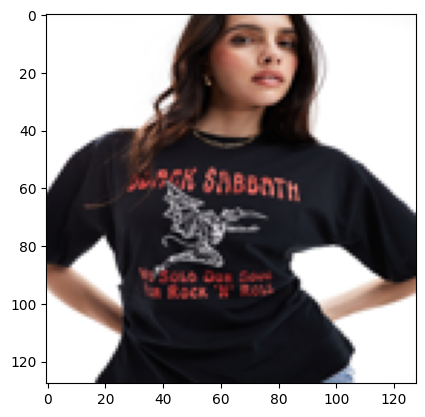

ca_images


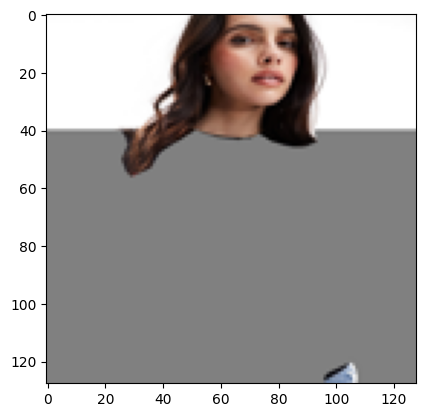

person_poses
garment_images


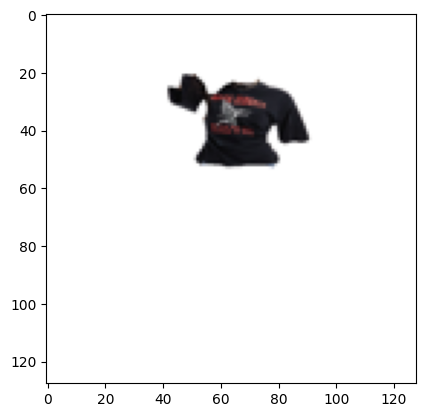

garment_poses


In [7]:
from matplotlib import pyplot as plt
for k,v in sample.items():
    try:
        print(k)
        plt.imshow(v.permute(1,2,0))
        plt.show()
    except Exception as e:
        pass


person_images


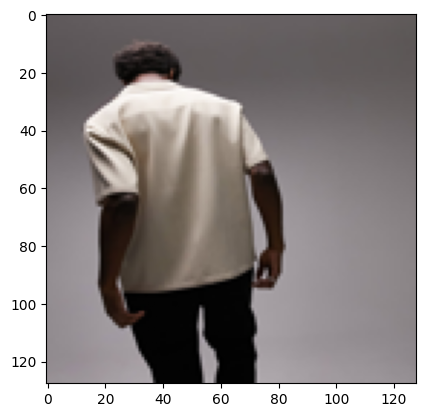

ca_images


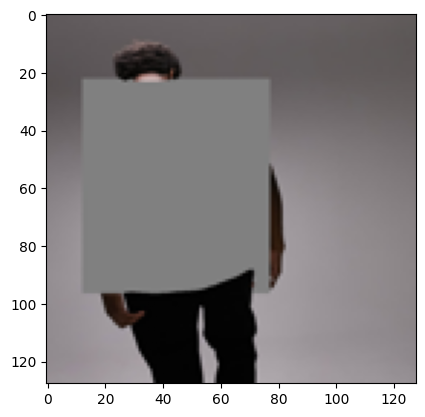

person_poses


RuntimeError: permute(sparse_coo): number of dimensions in the tensor input does not match the length of the desired ordering of dimensions i.e. input.dim() = 2 is not equal to len(dims) = 3

In [13]:
from tryondiffusion import TryOnImagen, TryOnImagenTrainer, get_unet_by_name, SyntheticTryonDataset, tryondiffusion_collate_fn, SyntheticTryonDatasetFromDisk

dataset = SyntheticTryonDatasetFromDisk()
for i in dataset:
    for k,v in i.items():
        # try:
        print(k)
        plt.imshow(v.permute(1,2,0))
        plt.show()
        plt.imsave('/mnt/datadrive/experiments/newalgo/samples_big/0/ca_0_3_sample.png', v.permute(1,2,0).numpy())
        # except Exception as e:
        #     pass
    break


In [5]:
import torch
xxx=  torch.load('/mnt/datadrive/asos_dataset/80756_203404/prepared_128/tensors_ready60k/366.pt')
xxx.keys()

dict_keys(['person_images', 'ca_images', 'person_poses', 'garment_images', 'garment_poses'])

In [8]:
import itertools 
x = [0,1,2]
list(itertools.permutations(x, 2))

[(0, 1), (0, 2), (1, 0), (1, 2), (2, 0), (2, 1)]

In [50]:
import pandas as pd

df_total = pd.read_csv('/home/roman/tryondiffusion_implementation/tryondiffusion_danny/total_40_k.csv')
df_total.head()


,name,label
0,3602_1270_1117.png,front
1,3602_1270_1118.png,back
2,3602_1270_1119.png,closeup
3,3602_1271_600.png,back
4,3602_1271_601.png,front


In [51]:
from pathlib import Path
old = pd.read_csv('all_imgs_clean_80756_total.csv')
old.head()

,fullpath,ds,bad,item_idx,selector_toofew,pose_512,pose_is_none
0,/mnt/datadrive/asos_dataset/3602/1270/1117.png,3602,False,3602_1270,False,b'\x80\x04\x95\xad\x01\x00\x00\x00\x00\x00\x00...,False
1,/mnt/datadrive/asos_dataset/3602/1270/1118.png,3602,False,3602_1270,False,b'\x80\x04\x95\xad\x01\x00\x00\x00\x00\x00\x00...,False
2,/mnt/datadrive/asos_dataset/3602/1270/1119.png,3602,False,3602_1270,False,b'\x80\x04\x95\xad\x01\x00\x00\x00\x00\x00\x00...,False
3,/mnt/datadrive/asos_dataset/3602/1271/600.png,3602,False,3602_1271,False,b'\x80\x04\x95\xad\x01\x00\x00\x00\x00\x00\x00...,False
4,/mnt/datadrive/asos_dataset/3602/1271/601.png,3602,False,3602_1271,False,b'\x80\x04\x95\xad\x01\x00\x00\x00\x00\x00\x00...,False


In [52]:
len(old)

80761

In [53]:
xxx = old['fullpath'].values[-1]

In [54]:
xxx = old[old['ds']=='4169_update']['fullpath'].values[0]

In [55]:
def getcvat_id(path):
    parts = Path(path).parts
    return '_'.join(parts[-3:])

getcvat_id(xxx)

'4169_update_8596_1_17810.png'

In [56]:
old['cvatid'] = old['fullpath'].apply(lambda x: getcvat_id(x))

In [57]:
df_total['cvatid'] = df_total['name']

In [58]:
merged = pd.merge(df_total, old.drop_duplicates(subset=['cvatid']), how='inner', on='cvatid')
len(merged)

39997

In [59]:
merged.head(5)

,name,label,cvatid,fullpath,ds,bad,item_idx,selector_toofew,pose_512,pose_is_none
0,3602_1270_1117.png,front,3602_1270_1117.png,/mnt/datadrive/asos_dataset/3602/1270/1117.png,3602,False,3602_1270,False,b'\x80\x04\x95\xad\x01\x00\x00\x00\x00\x00\x00...,False
1,3602_1270_1118.png,back,3602_1270_1118.png,/mnt/datadrive/asos_dataset/3602/1270/1118.png,3602,False,3602_1270,False,b'\x80\x04\x95\xad\x01\x00\x00\x00\x00\x00\x00...,False
2,3602_1270_1119.png,closeup,3602_1270_1119.png,/mnt/datadrive/asos_dataset/3602/1270/1119.png,3602,False,3602_1270,False,b'\x80\x04\x95\xad\x01\x00\x00\x00\x00\x00\x00...,False
3,3602_1271_600.png,back,3602_1271_600.png,/mnt/datadrive/asos_dataset/3602/1271/600.png,3602,False,3602_1271,False,b'\x80\x04\x95\xad\x01\x00\x00\x00\x00\x00\x00...,False
4,3602_1271_601.png,front,3602_1271_601.png,/mnt/datadrive/asos_dataset/3602/1271/601.png,3602,False,3602_1271,False,b'\x80\x04\x95\xad\x01\x00\x00\x00\x00\x00\x00...,False


In [60]:
len(df_total)

39997

In [61]:
merged = merged[['name', 'label', 'fullpath', 'ds', 'item_idx']]
merged.to_csv('merged_cvat40k.csv', index=False)

In [62]:
fronted = merged[merged['label']=='front']

In [63]:
counts = fronted['item_idx'].value_counts().to_dict()


In [64]:
fronted['selector_too_few'] = fronted['item_idx'].apply(lambda x: counts[x]<2)
fronted_filtered = fronted[~fronted['selector_too_few']]
len(fronted_filtered)

/tmp/ipykernel_427426/914564994.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fronted['selector_too_few'] = fronted['item_idx'].apply(lambda x: counts[x]<2)


19097

In [65]:
fronted_filtered[fronted_filtered['item_idx']=='7616_3567']

,name,label,fullpath,ds,item_idx,selector_too_few
32936,7616_3567_11332.png,front,/mnt/datadrive/asos_dataset/7616/3567/11332.png,7616,7616_3567,False
32937,7616_3567_11333.png,front,/mnt/datadrive/asos_dataset/7616/3567/11333.png,7616,7616_3567,False
32938,7616_3567_11334.png,front,/mnt/datadrive/asos_dataset/7616/3567/11334.png,7616,7616_3567,False


In [67]:
fronted_filtered.to_csv('fronted_filtered.csv', index=False)